In [39]:
# Подключение Google Drive в Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Импорт необходимых библиотек
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

In [41]:
# Путь к изображениям
SRC_DIR = "/content/drive/MyDrive/src"
print(os.listdir(SRC_DIR))

['airplane.jpg', 'phone.jpg', 'cat.jpg']


In [42]:
# ResNet блок
class ResNetBlock(tf.keras.layers.Layer):
    def __init__(self, filters):
        super(ResNetBlock, self).__init__()
        self.filters = filters
        # 1
        self.conv1 = layers.Conv2D(filters=filters, kernel_size=(3, 3), strides=1, padding="same")
        self.bn1 = layers.BatchNormalization()
        self.relu = layers.ReLU()
        # 2
        self.conv2 = layers.Conv2D(filters=filters, kernel_size=(3, 3), strides=1, padding="same")
        self.bn2 = layers.BatchNormalization()
        self.shortcut_conv = None
        self.shortcut_bn = None
    def build(self, input_shape):
        input_channels = input_shape[-1]
        if input_channels != self.filters:
            self.shortcut_conv = layers.Conv2D(filters=self.filters, kernel_size=(1, 1), strides=1, padding="same")
            self.shortcut_bn = layers.BatchNormalization()
    def call(self, inputs, training=False):
        shortcut = inputs
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        if self.shortcut_conv is not None:
            shortcut = self.shortcut_conv(shortcut)
            shortcut = self.shortcut_bn(shortcut, training=training)
        x = layers.Add()([x, shortcut])
        x = self.relu(x)
        return x
        
        

In [43]:
# Проверка
test_input = tf.random.normal((1, 32, 32, 3))
resnet_block = ResNetBlock(filters=64)
test_output = resnet_block(test_input, training=True)
print("Input shape:", test_input.shape)
print("Output shape:", test_output.shape)

Input shape: (1, 32, 32, 3)
Output shape: (1, 32, 32, 64)


In [44]:
# Простой модель с ResNet блоками
inputs = layers.Input(shape=(32, 32, 3))
x =  layers.Conv2D(64, (3, 3), padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = ResNetBlock(64)(x)
x = ResNetBlock(64)(x)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
resnet_model = Model(inputs, outputs)
resnet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_block_10 (ResNetBlock)  │ (None, 32, 32, 64)     │        74,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_block_11 (ResNetBlock)  │ (None, 32, 32, 64)     │        74,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,434 (591.54 KB)

 Trainable params: 150,794 (589.04 KB)

 Non-trainable params: 640 (2.50 KB)

**Задание 2**

In [45]:
# Загрузка MobileNetV2
mobilenet = MobileNetV2(weights="imagenet")

In [46]:
# Функция  загрузки и предобработки изображения
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img, img_array

Файл: Кот
Путь: /content/drive/MyDrive/src/cat.jpg


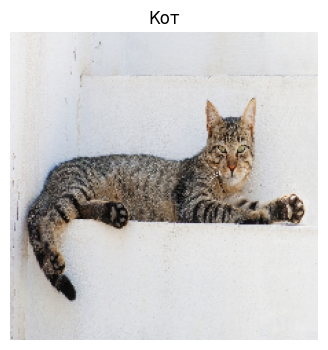

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Top-3 предсказания MobileNetV2:
1. tabby — вероятность: 0.4117
2. Egyptian_cat — вероятность: 0.2516
3. tiger_cat — вероятность: 0.1021
Файл: Телефон
Путь: /content/drive/MyDrive/src/phone.jpg


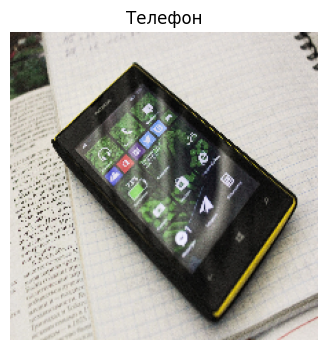

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Top-3 предсказания MobileNetV2:
1. iPod — вероятность: 0.4093
2. remote_control — вероятность: 0.0840
3. wallet — вероятность: 0.0362
Файл: Самолет
Путь: /content/drive/MyDrive/src/airplane.jpg


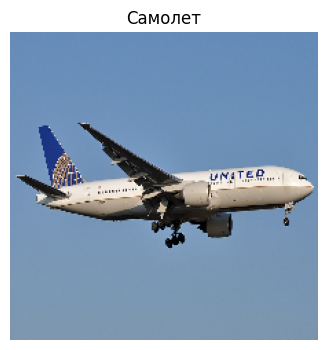

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Top-3 предсказания MobileNetV2:
1. airliner — вероятность: 0.9609
2. wing — вероятность: 0.0137
3. warplane — вероятность: 0.0017


In [47]:
# Классификация изображений
image_paths = {
    "Кот": "/content/drive/MyDrive/src/cat.jpg",
    "Телефон": "/content/drive/MyDrive/src/phone.jpg",
    "Самолет": "/content/drive/MyDrive/src/airplane.jpg"
}
for image_name, img_path in image_paths.items():
    print("Файл:", image_name)
    print("Путь:", img_path)
    if not os.path.exists(img_path):
        print("Файл не найден. Проверь путь и название файла.")
        continue
    original_img, prepared_img = load_and_preprocess_image(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(original_img)
    plt.axis("off")
    plt.title(image_name)
    plt.show()
    predictions = mobilenet.predict(prepared_img)
    decoded_predictions = decode_predictions(predictions, top=3)[0]
    print("Top-3 предсказания MobileNetV2:")
    for i, prediction in enumerate(decoded_predictions, start=1):
        class_id, class_name, probability = prediction
        print(f"{i}. {class_name} — вероятность: {probability:.4f}")